Optimal Threshold for Max F1-Score: 1.0000


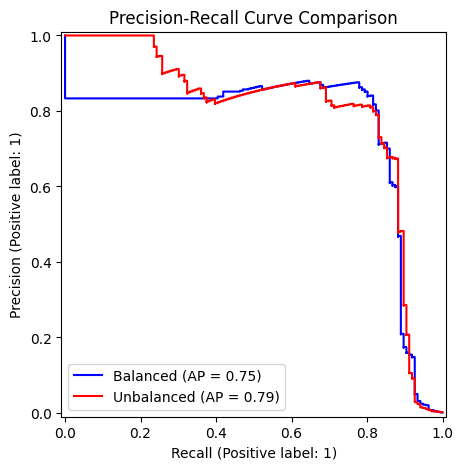

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

data = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

scaler = StandardScaler()
data[['Time', 'Amount']] = scaler.fit_transform(data[['Time', 'Amount']])

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
model_balanced.fit(X_train, y_train)

model_unbalanced = LogisticRegression(max_iter=1000)
model_unbalanced.fit(X_train, y_train)

y_proba = model_balanced.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold for Max F1-Score: {best_threshold:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_estimator(model_balanced, X_test, y_test, name="Balanced", ax=ax, color="blue")
PrecisionRecallDisplay.from_estimator(model_unbalanced, X_test, y_test, name="Unbalanced", ax=ax, color="red")
plt.title("Precision-Recall Curve Comparison")
plt.show()